In [1]:
import cv2
import numpy as np

# Đọc ảnh
img = cv2.imread("image.png")

# Blur ảnh
blur = cv2.GaussianBlur(img, (0, 0), sigmaX=3)

# Hệ số sharpen
alpha = 1.5

# sharp = image + α*(image - blur)
sharp = cv2.addWeighted(
    img,
    1 + alpha,
    blur,
    -alpha,
    0
)

cv2.imwrite("sharp.jpg", sharp)

True

In [2]:
import cv2

img = cv2.imread("image.png", 0)

th = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,  # block size (số lẻ)
    2    # C
)

cv2.imwrite("adaptive.jpg", th)

True

In [6]:
import cv2
from skimage.filters import threshold_sauvola

img = cv2.imread("image.png", 0)

window_size = 25

thresh = threshold_sauvola(
    img,
    window_size=window_size,
    k=0.25
)

binary = (img > thresh).astype("uint8") * 255

cv2.imwrite("sauvola.jpg", binary)

True

In [9]:
import cv2
import numpy as np

img = cv2.imread("image2.png")

# 1. Gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. CLAHE - tăng tương phản nhẹ
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
clahe_img = clahe.apply(gray)

# 3. Unsharp Mask - làm nét nhẹ
blur = cv2.GaussianBlur(clahe_img, (0, 0), sigmaX=1.2)

sharp = cv2.addWeighted(
    clahe_img,
    1.8,   # original weight
    blur,
    -0.8,  # blur weight
    0
)

# 4. Bilateral Filter - giảm noise nhưng giữ cạnh
result = cv2.bilateralFilter(
    sharp,
    d=5,
    sigmaColor=40,
    sigmaSpace=40
)

cv2.imwrite("plate_processed.jpg", result)

True

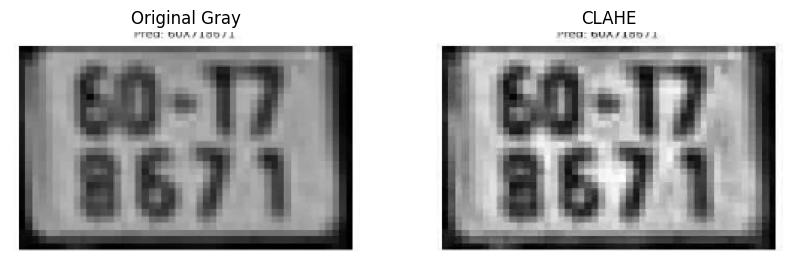

In [11]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image1.png")

# Convert sang grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Tạo CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Áp dụng CLAHE
clahe_img = clahe.apply(gray)

# Hiển thị
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original Gray")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("CLAHE")
plt.imshow(clahe_img, cmap="gray")
plt.axis("off")

plt.show()